# F - planning - get object calibrated results (06.01.23)

1. Get calibration function
    - Can saved data be used for that - yes
2. Get location mapping
    - use saved data to generate mapping
3. Rerun the GMM generation script, generate object probability costmap (200x200) for object calibrated location and presence
    - .
    

In [3]:
# imports

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F

from binnings import *
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from helper import find_gaussians_cal, get_clusters, rot

In [4]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

In [5]:
indices_val, indices_test = train_test_split(np.arange(0, 5119), test_size=0.8, random_state=1001)

In [6]:
def get_val_test(probs, ys, indices, indices_test = indices_test, indices_val = indices_val):
## Get test indices

    all_indices_test = []
    all_indices_val = []

    for i in indices_test:  # Why this used?
        all_indices_test += list(np.where(i == indices)[0])

    for i in indices_val:
        all_indices_val += list(np.where(i == indices)[0])

    all_indices_test = np.array(all_indices_test)
    all_indices_test.sort()

    all_indices_val = np.array(all_indices_val)
    all_indices_val.sort()
    
    return (probs[all_indices_val], ys[all_indices_val]), (probs[all_indices_test], ys[all_indices_test])

In [7]:
from betacal import BetaCalibration

def cal_obj(probs_val, probs_test, ys_val, ys_test):
    
    model = BetaCalibration()  # Is beta or Iso used for final?
    model.fit(probs_val, ys_val)
    
    ewb = EqualWidthBinning(np.clip(probs_test, 0, 1), ys_test, None, n_bins = 10)
    print("ECE test uncal:", ewb.ECE_abs)
    
    probs_test_objcal = model.predict(probs_test)
    
    ewb = EqualWidthBinning(probs_test_objcal, ys_test, None, n_bins = 10)
    print("ECE test cal:", ewb.ECE_abs)
    
    return model

In [8]:
# Presence uncertainty

res_pres = np.load("results_all_presence_uncertainty_n=0_09_27_22_pw.npz")

probs_pres = res_pres["p"]
#probs_pres_cal = res_pres["p_cal"]
ys_pres = res_pres["y"]
dist_means_pres = res_pres["dist_mean"]
indices_pres = res_pres["indices"]

(probs_val, ys_val), (probs_test, ys_test) = get_val_test(probs_pres, ys_pres, indices_pres)
#(probs_cal_val, _), (probs_cal_test, _) = get_val_test(probs_pres_cal, ys_pres, indices_pres)

In [9]:
# Location uncertainty
data_np = np.load("results_all_location_uncertainty_n=0_09_27_22_pw.npz")
quantiles = data_np["q"]
indices_loc = data_np["indices"]

# Loaction uncertainty calibrated
data_np = np.load("results_all_location_uncertainty_cal_n=0_09_27_22_pw.npz")
quantiles_cal = data_np["q"]
indices_loc_cal = data_np["indices"]

(quantiles_cal_val, _), (quantiles_cal_test, _) = get_val_test(quantiles_cal, quantiles_cal, indices_loc_cal)

(quantiles_val, _), (quantiles_test, _) = get_val_test(quantiles, quantiles, indices_loc)

### Get calibration map for presence

In [10]:
beta_model = cal_obj(probs_val, probs_test, ys_val, ys_test)
# No need to clip if using Beta, as it is doing inside the algorithm.

ECE test uncal: 0.1838914146721039
ECE test cal: 0.018211231742214697


### Get calibration map for location

In [11]:
def q_cal_map(q, inp_val, l = 100, method = "direction"):
    qs = np.linspace(1/l, 1, l)
    
    if method == "direction":
        i = 0
    else:
        i = 1
    
    wh = np.quantile(inp_val[:, i], qs)  # dir. error
    #h = np.quantile(inp_val[:, 1], qs)  # distance
    #w_cal = np.interp(np.quantile(inp_test[:,0], qs), w, qs)  # Why this way is correct? for w corresponds qs
    #h_cal = np.interp(np.quantile(inp_test[:,1], qs), h, qs)
    
    #w_cal = np.interp(np.quantile(inp_test[:,0], qs), qs, w)
    #h_cal = np.interp(np.quantile(inp_test[:,1], qs), qs, h)

    return np.interp(q, wh, qs)

### Generate GMMs and get costmaps from these

In [12]:
def get_corners(pxl, angle, increments = 10, center = [99.5, 99.5]):
    
    inc_size = 1/increments
    
    all_corners = []
    
    for inc_x in range(increments):        
        for inc_y in range(increments):
            corners_xy = [pxl + [inc_x*inc_size, inc_y*inc_size], pxl + [(inc_x+1)*inc_size, (inc_y+1)*inc_size], 
                          pxl + [(inc_x+1)*inc_size, inc_y*inc_size], pxl + [inc_x*inc_size, (inc_y+1)*inc_size]]
                        
            corners_xy -= np.array(center)
            #print(corners_xy)
            corners_xy_new = rot(angle) @ corners_xy.T
            
            all_corners.append(corners_xy_new)
                
    return np.array(all_corners)

In [18]:
def get_object_costmaps(segm_ped_p, segm_ped_y, center_ped_p, indices_inp, nr_future = 0, val_pixels = 40920000):    

    center = [99.5, 99.5]
    
    costmaps_segm = []
    costmaps_segm_cal = []
    presence_ps_all = []
    presence_ps_all_cal = []
    
    ids = []

    for count, idx in enumerate(indices_inp):

        if count % 100 == 0:
            print(count)

        
        print(count, idx)
        
        # Prep data          
        center_ped_p_new = center_ped_p[nr_future, idx].copy()
        segm_p_new = segm_ped_p[nr_future, idx].copy()
            
        # Get GMMs

        p, _, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        #cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_costmaps = []

        if masks_gmm == None:
            #ids.append([idx, 0])
            costmaps_segm_cal.append([])
            #presence_ps_all.append(presence_ps)
            presence_ps_all_cal.append([])
            continue
            
        angles = []
        
        presence_ps = p
        presence_ps_cal = beta_model.predict(p)
        costmaps_gmm = []
        costmaps_gmm_cal = []

        for i, (pr, dist, m) in enumerate(zip(p, dists, masks_gmm)):

            costmap = np.zeros((200,200))
            costmap_cal = np.zeros((200,200))

            #sum_cost = 0
            sum_cost_rot = 0
            pixel_probs = []
            
            # Get 1-d normal distributions
            dist_mean_re = dist.mean - center

            angle = np.rad2deg(np.math.atan2(*dist_mean_re))
            angles.append(angle)

            # Match found, rotate axes for norm distribution
            dist_mean_new = rot(angle) @ dist_mean_re
            cov_new = rot(angle) @ dist.cov @ rot(angle).T              

            norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
            norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))
            
            pixels_gmm = np.array(np.where(m == 1)).T
            
            print("Pixels:", pixels_gmm.shape)

            # Find pixel values for distributions
            for pixel_xy in pixels_gmm:    


                #ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
                all_corners = get_corners(pixel_xy, angle, increments=3, center = center)    

                print(all_corners)

                res_x = norm_x.cdf([all_corners[:, 0].min(axis=1), all_corners[:, 0].max(axis=1)])
                res_y = norm_y.cdf([all_corners[:, 1].min(axis=1), all_corners[:, 1].max(axis=1)])
                
                # Calibrate location res_x and res_y  # dir. error and distance
                
                res_x_cal = q_cal_map(res_x, quantiles_val)
                res_y_cal = q_cal_map(res_y, quantiles_val, method="distance")
                
                #return res_x, res_y, pr, all_corners, norm_x

                #pixel_prob = np.sum((res_x[1] - res_x[0])*(res_y[1] - res_y[0]))
                pixel_prob_cal = np.sum((res_x_cal[1] - res_x_cal[0])*(res_y_cal[1] - res_y_cal[0]))
                
                # Calib presence
                pr_cal = beta_model.predict([pr])[0]
                
                #costmap[pixel_xy[0], pixel_xy[1]] = pixel_prob*pr*5
                costmap_cal[pixel_xy[0], pixel_xy[1]] = pixel_prob_cal*pr_cal*5
                
                #sum_cost_rot += pixel_prob
                #sum_cost += dist.cdf([pixel_xy[0] + 1, pixel_xy[1] + 1]) + dist.cdf([pixel_xy[0], pixel_xy[1]]) - dist.cdf([pixel_xy[0]+1, pixel_xy[1]]) - dist.cdf([pixel_xy[0], pixel_xy[1]+1])

                #costmaps_gmm.append(costmap)
                costmaps_gmm_cal.append(costmap_cal)
            #print(sum_cost_rot)

        #return costmaps_gmm, presence_ps, masks_gmm
    
        #costmaps_segm.append(np.sum(costmaps_gmm, axis=0).transpose(1,0))
        costmaps_segm_cal.append(np.sum(costmaps_gmm_cal, axis=0).transpose(1,0))
        #presence_ps_all.append(presence_ps)
        presence_ps_all_cal.append(presence_ps_cal)
        
        #return costmaps_segm, costmaps_segm_cal
        
    #return ids
                
    np.savez("results_all_costmaps_object_cal_n=%i_09_01_23_pw_val.npz" % nr_future, costmaps=costmaps_segm, costmaps_cal = costmaps_segm_cal, ps = presence_ps_all, ps_cal = presence_ps_all_cal)
    
    return costmaps_segm, costmaps_segm_cal, presence_ps_all, presence_ps_all_cal

In [15]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [16]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(results_name = "instance_center", label_name = "centerness", flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

#center_ped_y = segm_ped_data["y"]
center_ped_p = center_ped_data["p"]

In [ ]:
#res_x, res_y, pr, all_corners, norm_x = get_object_costmaps(segm_ped_p, segm_ped_y, center_ped_p, range(0, segm_ped_p.shape[1]), 
#                                   nr_future = 0)

In [ ]:
_, costmaps_segm_cal_val, _, presence_ps_all_cal_val = get_object_costmaps(segm_ped_p, segm_ped_y, 
                                                                                             center_ped_p, 
                                                                                             indices_inp=indices_val, 
                                                                                             nr_future = 0)

In [17]:
indices_test

array([4275, 1848, 2569, ..., 3342,  714, 3868])

In [56]:
ids = get_object_costmaps(segm_ped_p, segm_ped_y, center_ped_p, indices_inp=indices_test, nr_future = 0)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000


In [37]:
costmaps_segm, costmaps_segm_cal, presence_ps_all, presence_ps_all_cal = get_object_costmaps(segm_ped_p, segm_ped_y, 
                                                                                             center_ped_p, 
                                                                                             indices_inp=indices_test, 
                                                                                             nr_future = 0)

0
0 4275
1 1848
2 2569
3 2428
4 2607
Pixels: (4880, 2)
Pixels: (67, 2)
Pixels: (3191, 2)
Pixels: (209, 2)
Pixels: (480, 2)
Pixels: (1712, 2)
Pixels: (181, 2)
Pixels: (324, 2)
5 2441
6 4174
Pixels: (8801, 2)
7 1032
Pixels: (742, 2)
Pixels: (63, 2)
Pixels: (182, 2)
Pixels: (3309, 2)
Pixels: (1008, 2)
8 4222
9 3052
Pixels: (233, 2)
Pixels: (54, 2)
Pixels: (989, 2)
Pixels: (77, 2)
Pixels: (72, 2)
Pixels: (16637, 2)
Pixels: (103, 2)
10 2772
Pixels: (1794, 2)
Pixels: (944, 2)
Pixels: (1863, 2)
11 3073
Pixels: (4283, 2)
Pixels: (27812, 2)


KeyboardInterrupt: 

In [ ]:
presence_ps_all_cal_fix

In [60]:
j = 0

costmaps_segm_cal_fix = []
presence_ps_all_cal_fix = []

for idx, i in ids:
    if i == 0:
        costmaps_segm_cal_fix.append(np.zeros((200, 200)))
        presence_ps_all_cal_fix.append([])
    else:
        costmaps_segm_cal_fix.append(costmaps_segm_cal[j])
        presence_ps_all_cal_fix.append(presence_ps_all_cal[j])
        j += 1

In [70]:
#np.savez("results_all_costmaps_object_cal_n=%i_09_01_23_pw_fix.npz" % 0, costmaps_cal = costmaps_segm_cal_fix, ps_cal = presence_ps_all_cal_fix)

In [61]:
len(costmaps_segm_cal_fix)

4096

In [28]:
indices_test

array([4275, 1848, 2569, ..., 3342,  714, 3868])

In [36]:
segm_ped_p.shape

(5, 5119, 200, 200)

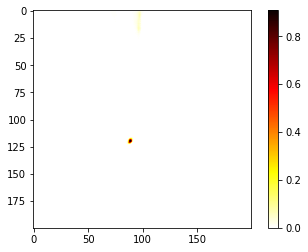

In [67]:
plt.imshow(segm_ped_p[0, indices_test[6]], cmap="hot_r")
plt.colorbar()

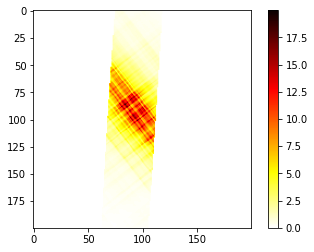

In [66]:
plt.imshow(costmaps_segm_cal_fix[6], cmap="hot_r")
plt.colorbar()

### 

In [68]:
plt.imshow(np.sum(masks, axis=0))

NameError: name 'masks' is not defined

In [ ]:
hm = plt.imshow(segm_ped_p[0,0], cmap="hot_r")
plt.colorbar(hm)

In [ ]:
hm = plt.imshow(np.sum(costmaps_gmm, axis=0).transpose(1,0), cmap="hot_r")
plt.colorbar(hm)

### Testing code

In [ ]:
p

In [ ]:
plt.imshow(np.array(masks_gmm)[0])

In [ ]:
p

In [ ]:
pixels_gmm = np.array(np.where(masks_gmm[0] == 1)).T
dist = dists[0]
center = [99.5, 99.5]
angles = []

In [ ]:
dist.cdf([125, 177])

In [ ]:
presence_ps = []


costmaps_gmm = []

costmap = np.zeros((200,200))

#sum_cost = 0
sum_cost_rot = 0
pixel_probs = []

for pixel_xy in pixels_gmm:    
    
    dist_mean_re = dist.mean - center

    angle = np.rad2deg(np.math.atan2(*dist_mean_re))
    angles.append(angle)

    # Match found, rotate axes for norm distribution
    dist_mean_new = rot(angle) @ dist_mean_re
    cov_new = rot(angle) @ dist.cov @ rot(angle).T              

    norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
    norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))

    #ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
    all_corners = get_corners(pixel_xy, angle, increments=10)    

    #print(all_corners)
    
    res_x = norm_x.cdf([all_corners[:, 0].min(axis=1), all_corners[:, 0].max(axis=1)])
    res_y = norm_y.cdf([all_corners[:, 1].min(axis=1), all_corners[:, 1].max(axis=1)])

    pixel_prob = np.sum((res_x[1] - res_x[0])*(res_y[1] - res_y[0]))
    costmap[pixel_xy[0], pixel_xy[1]] = pixel_prob*p*5
    sum_cost_rot += pixel_prob
    #sum_cost += dist.cdf([pixel_xy[0] + 1, pixel_xy[1] + 1]) + dist.cdf([pixel_xy[0], pixel_xy[1]]) - dist.cdf([pixel_xy[0]+1, pixel_xy[1]]) - dist.cdf([pixel_xy[0], pixel_xy[1]+1])

In [ ]:
costmap.sum()

In [ ]:
sum_cost_rot

In [ ]:
sum_cost

In [ ]:
all_corners = get_corners(pixel_xy, angle)  #- np.array(center)

In [ ]:
res_x = norm_x.cdf([all_corners[:, 0].min(axis=1), all_corners[:, 0].max(axis=1)])
res_y = norm_y.cdf([all_corners[:, 1].min(axis=1), all_corners[:, 1].max(axis=1)])

np.sum((res_x[1] - res_x[0])*(res_y[1] - res_y[0]))

In [ ]:
res_x[1] - res_x[0]

In [ ]:
norm_x.cdf([corners_xy_new[0].min(), corners_xy_new[0].max()])

In [ ]:
norm_y.cdf([corners_xy_new[1].min(), corners_xy_new[1].max()])

In [ ]:
0.66857191 - 0.14140208 


In [ ]:
0.00441446 - 0.00048545

In [ ]:
0.5271698300000001*0.00392901


In [ ]:
[0.14140208, 0.66857191]
[0.00048545, 0.00441446]

In [ ]:
dists[0].cdf(pixel_xy)